# Resource Underutilization and Overutilization in Python

## Outline

- what underutilization and overutilization mean
- why utilization matters in computing systems
- the Sleeping Barber problem as a queue-based system
- a simulation of a barber shop with:
  - one barber as the service resource
  - waiting chairs as bounded queue capacity
  - customers as incoming jobs
- three system regimes:
  - **underutilized**
  - **balanced**
  - **overutilized**
- metrics and plots for:
  - throughput
  - busy/idle time
  - utilization
  - dropped customers

---

## What you should expect to learn from this notebook

1. Explain the difference between **underutilization** and **overutilization**
2. Relate the Sleeping Barber problem to real-world systems
3. Measure system utilization from a simulation
4. Interpret how arrival rate and service rate affect performance
5. Connect this example to servers, CPUs, APIs, and distributed workers

In [1]:
import threading
import time
import random
from queue import Queue, Full, Empty
from dataclasses import dataclass, asdict

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

random.seed(42)

## 1. What is resource utilization?

**Resource utilization** describes how much of a resource's capacity is actually being used.

Examples of resources:
- CPU cores
- GPUs
- database connections
- web servers
- worker processes
- network links
- storage devices

### Two important extremes

### Underutilization
A resource is available but sits idle much of the time.

Examples:
- CPU is mostly idle
- server waits for requests
- worker pool has too few tasks

### Overutilization
Demand exceeds the effective capacity of the resource.

Examples:
- request rate exceeds service rate
- queue becomes full
- response time increases
- jobs are dropped or delayed

This notebook uses the Sleeping Barber problem to make those ideas concrete.

## 2. The Sleeping Barber example

The Sleeping Barber problem maps very naturally to system performance concepts.

### Model mapping

- **Barber** → server / worker / CPU
- **Customers** → jobs / requests / tasks
- **Waiting chairs** → bounded queue / buffer
- **Haircut time** → service time
- **Customer arrival interval** → arrival rate

Mapping this model to the following concepts is straightforward:

- utilization
- throughput
- queueing
- overload
- admission control
- dropped work

## 3. The Sleeping Barber problem

### Story
- one barber works in a barber shop
- there is one barber chair
- there are a limited number of waiting chairs
- if no customers are present, the barber sleeps
- if a customer arrives:
  - if the barber is idle, service starts when the barber wakes
  - if the barber is busy but a waiting chair is available, the customer waits
  - if the waiting room is full, the customer leaves

### Why it matters?
This problem is a classic bounded-buffer and synchronization model.

It is also clearly shows cases of:
- idle resources
- saturated resources
- queue growth
- dropped requests

In [2]:
@dataclass
class BarberSimulationSummary:
    scenario: str
    total_customers: int
    served_customers: int
    dropped_customers: int
    waiting_chairs: int
    haircut_time_s: float
    mean_interarrival_s: float
    elapsed_s: float
    barber_busy_time_s: float
    barber_idle_time_s: float
    barber_utilization: float
    throughput_customers_per_s: float

## 4. Simulation design

We simulate:

- a single barber thread
- a bounded waiting room using `queue.Queue(maxsize=...)`
- customers arriving over time
- service events and drop events

### Measured metrics

We track:

- **served customers**
- **dropped customers**
- **barber busy time**
- **barber idle time**
- **barber utilization**
- **throughput**

### Notes

This is a didactic simulation, not a formal queueing-theory proof.  
Its purpose is to build intuition with reproducible Python code.

In [3]:
def run_sleeping_barber_simulation(
    scenario_name: str,
    total_customers: int,
    waiting_chairs: int,
    haircut_time_s: float,
    mean_interarrival_s: float,
    arrival_jitter_s: float = 0.0,
):
    """
    Run a Sleeping Barber simulation and compute utilization metrics.

    Parameters
    ----------
    scenario_name : str
        Label for the scenario.
    total_customers : int
        Number of customers generated in the simulation.
    waiting_chairs : int
        Number of chairs in the waiting room.
    haircut_time_s : float
        Time required to serve one customer.
    mean_interarrival_s : float
        Average time between arrivals.
    arrival_jitter_s : float
        Random perturbation added/subtracted to the interarrival delay.

    Returns
    -------
    summary : BarberSimulationSummary
    events : list[dict]
    """
    waiting_room = Queue(maxsize=waiting_chairs)
    stop_token = object()

    served_customers = []
    dropped_customers = []
    events = []

    busy_time = 0.0
    idle_time = 0.0
    state_lock = threading.Lock()

    def barber():
        nonlocal busy_time, idle_time

        while True:
            idle_start = time.perf_counter()
            customer = waiting_room.get()
            idle_end = time.perf_counter()

            with state_lock:
                idle_time += idle_end - idle_start

            if customer is stop_token:
                waiting_room.task_done()
                events.append({"event": "barber_stop"})
                break

            customer_id = customer
            service_start = time.perf_counter()
            events.append({"event": "service_start", "customer_id": customer_id, "queue_size": waiting_room.qsize()})
            time.sleep(haircut_time_s)
            service_end = time.perf_counter()

            with state_lock:
                busy_time += service_end - service_start

            served_customers.append(customer_id)
            events.append({"event": "service_end", "customer_id": customer_id, "queue_size": waiting_room.qsize()})
            waiting_room.task_done()

    barber_thread = threading.Thread(target=barber)
    start_time = time.perf_counter()
    barber_thread.start()

    for customer_id in range(total_customers):
        events.append({"event": "arrival", "customer_id": customer_id, "queue_size": waiting_room.qsize()})
        try:
            waiting_room.put(customer_id, block=False)
            events.append({"event": "joined_queue", "customer_id": customer_id, "queue_size": waiting_room.qsize()})
        except Full:
            dropped_customers.append(customer_id)
            events.append({"event": "dropped", "customer_id": customer_id, "queue_size": waiting_room.qsize()})

        interarrival = mean_interarrival_s
        if arrival_jitter_s > 0:
            interarrival += random.uniform(-arrival_jitter_s, arrival_jitter_s)
            interarrival = max(0.0, interarrival)

        time.sleep(interarrival)

    waiting_room.join()
    waiting_room.put(stop_token)
    barber_thread.join()
    end_time = time.perf_counter()

    elapsed_s = end_time - start_time
    utilization = busy_time / elapsed_s if elapsed_s > 0 else 0.0
    throughput = len(served_customers) / elapsed_s if elapsed_s > 0 else 0.0

    summary = BarberSimulationSummary(
        scenario=scenario_name,
        total_customers=total_customers,
        served_customers=len(served_customers),
        dropped_customers=len(dropped_customers),
        waiting_chairs=waiting_chairs,
        haircut_time_s=haircut_time_s,
        mean_interarrival_s=mean_interarrival_s,
        elapsed_s=elapsed_s,
        barber_busy_time_s=busy_time,
        barber_idle_time_s=idle_time,
        barber_utilization=utilization,
        throughput_customers_per_s=throughput,
    )

    return summary, events

## 5. Three scenarios

We now run three scenarios with the same barber service time, but different arrival rates.

### Scenario A — Underutilized
Customers arrive slowly.

Expected effect:
- barber spends a lot of time idle
- very few or no drops
- low utilization

### Scenario B — Balanced
Customers arrive at a rate closer to the service rate.

Expected effect:
- barber is busy a healthy fraction of the time
- few or no drops
- utilization is high but not extreme

### Scenario C — Overutilized
Customers arrive too quickly.

Expected effect:
- barber is almost always busy
- waiting room fills up
- some customers are dropped
- throughput cannot increase much beyond service capacity

In [4]:
under_summary, under_events = run_sleeping_barber_simulation(
    scenario_name="Underutilized",
    total_customers=30,
    waiting_chairs=3,
    haircut_time_s=0.08,
    mean_interarrival_s=0.18,
    arrival_jitter_s=0.02,
)

balanced_summary, balanced_events = run_sleeping_barber_simulation(
    scenario_name="Balanced",
    total_customers=30,
    waiting_chairs=3,
    haircut_time_s=0.08,
    mean_interarrival_s=0.09,
    arrival_jitter_s=0.015,
)

over_summary, over_events = run_sleeping_barber_simulation(
    scenario_name="Overutilized",
    total_customers=30,
    waiting_chairs=3,
    haircut_time_s=0.08,
    mean_interarrival_s=0.03,
    arrival_jitter_s=0.01,
)

summary_df = pd.DataFrame([
    asdict(under_summary),
    asdict(balanced_summary),
    asdict(over_summary),
])

summary_df

,scenario,total_customers,served_customers,dropped_customers,waiting_chairs,haircut_time_s,mean_interarrival_s,elapsed_s,barber_busy_time_s,barber_idle_time_s,barber_utilization,throughput_customers_per_s
0,Underutilized,30,30,0,3,0.08,0.18,5.313889,2.404672,2.908696,0.452526,5.645583
1,Balanced,30,30,0,3,0.08,0.09,2.684431,2.404689,0.279254,0.895791,11.175554
2,Overutilized,30,15,15,3,0.08,0.03,1.202932,1.202375,0.000200,0.999536,12.469531


### First interpretation

Pay special attention to these columns:

- `served_customers`
- `dropped_customers`
- `barber_busy_time_s`
- `barber_idle_time_s`
- `barber_utilization`
- `throughput_customers_per_s`

Typical pattern:

- **Underutilized** → low utilization, high idle time
- **Balanced** → good utilization, little waste
- **Overutilized** → near-saturated barber, higher drops, throughput plateaus

## 6. Plot the key metrics

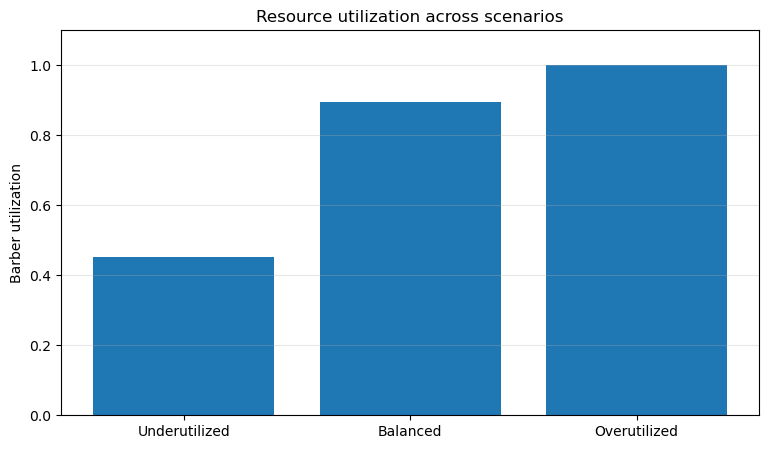

In [5]:
plt.figure(figsize=(9, 5))
plt.bar(summary_df["scenario"], summary_df["barber_utilization"])
plt.ylabel("Barber utilization")
plt.title("Resource utilization across scenarios")
plt.ylim(0, 1.1)
plt.grid(axis="y", alpha=0.3)
plt.show()

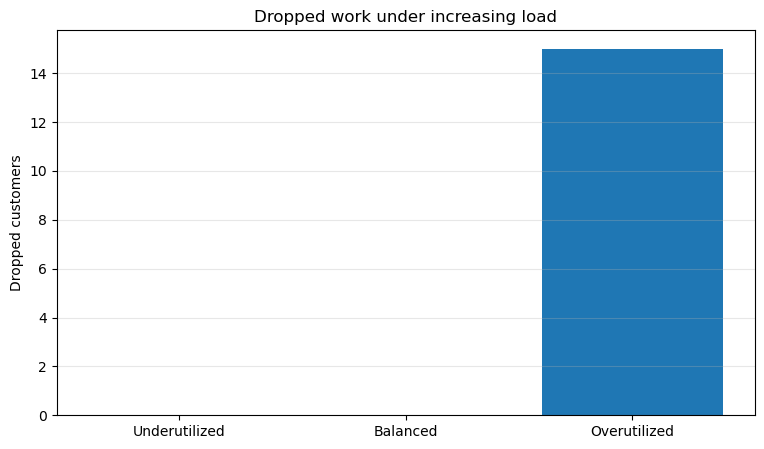

In [6]:
plt.figure(figsize=(9, 5))
plt.bar(summary_df["scenario"], summary_df["dropped_customers"])
plt.ylabel("Dropped customers")
plt.title("Dropped work under increasing load")
plt.grid(axis="y", alpha=0.3)
plt.show()

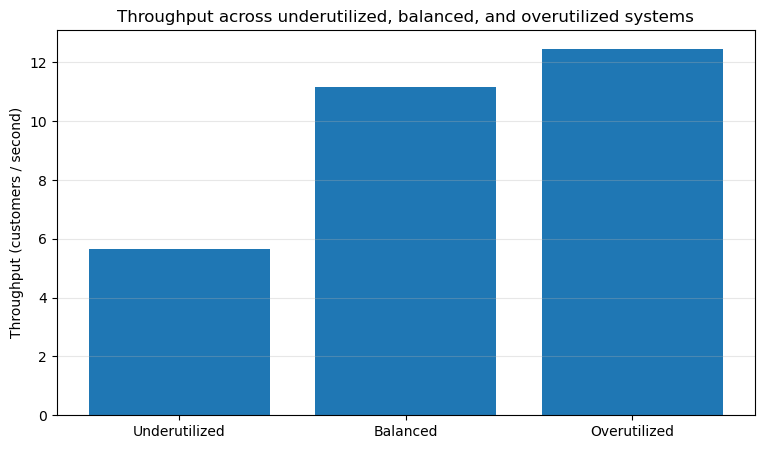

In [7]:
plt.figure(figsize=(9, 5))
plt.bar(summary_df["scenario"], summary_df["throughput_customers_per_s"])
plt.ylabel("Throughput (customers / second)")
plt.title("Throughput across underutilized, balanced, and overutilized systems")
plt.grid(axis="y", alpha=0.3)
plt.show()

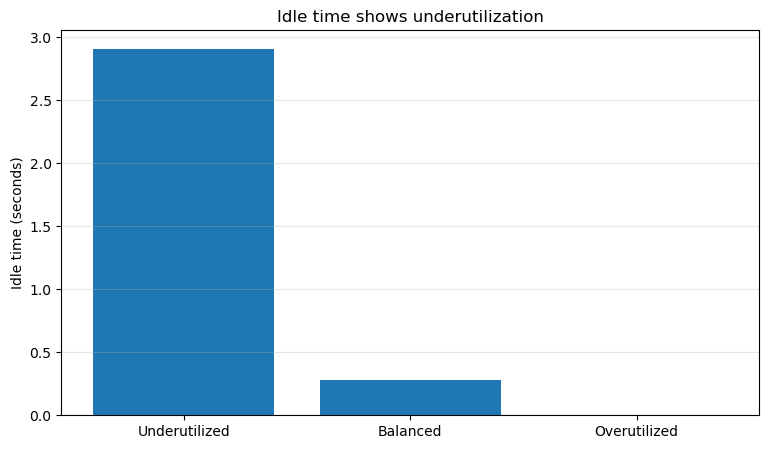

In [8]:
plt.figure(figsize=(9, 5))
plt.bar(summary_df["scenario"], summary_df["barber_idle_time_s"])
plt.ylabel("Idle time (seconds)")
plt.title("Idle time shows underutilization")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 7. Why throughput does not grow forever

A key lesson in system design is this:

> increasing load does not increase throughput forever.

Why?

Because the barber has a fixed service rate.

If a haircut takes about `0.08` seconds, then the barber can serve only a limited number of customers per second.

Once demand exceeds that capacity:

- the queue fills
- waiting grows
- customers are dropped
- throughput stops scaling significantly

This is the same pattern seen in real computing systems.

## 8. Analogies with real world cases

### Web server
- barber = server worker
- customers = HTTP requests
- waiting chairs = request queue

### CPU core
- barber = CPU
- customers = runnable tasks
- waiting chairs = scheduler queue

### Database connection pool
- barber = database connection
- customers = incoming queries
- waiting chairs = pool wait slots

### GPU serving
- barber = GPU worker
- customers = inference jobs
- waiting chairs = request buffer

The core tradeoff is always similar:
- too little work → underutilization
- too much work → overload
- somewhere in between → healthy utilization

## 9. Event timeline utilities

The simulation above also produced an event log.  
We now define a helper function to inspect how many arrivals, services, and drops occurred in each scenario.

In [9]:
def event_counts(events):
    counts = {}
    for event in events:
        key = event["event"]
        counts[key] = counts.get(key, 0) + 1
    return counts

event_summary_df = pd.DataFrame([
    {"scenario": "Underutilized", **event_counts(under_events)},
    {"scenario": "Balanced", **event_counts(balanced_events)},
    {"scenario": "Overutilized", **event_counts(over_events)},
]).fillna(0)

event_summary_df

,scenario,arrival,joined_queue,service_start,service_end,barber_stop,dropped
0,Underutilized,30,30,30,30,1,0.0
1,Balanced,30,30,30,30,1,0.0
2,Overutilized,30,15,15,15,1,15.0


## 10. Utilization as a fraction of time

A common metric in performance engineering is:

\[
\text{Utilization} = \frac{\text{busy time}}{\text{total elapsed time}}
\]

Interpretation:

- near **0** → resource is mostly idle
- moderate/high but below saturation → efficient use
- near **1** → resource is fully saturated

Important subtlety:

A utilization close to **100%** is not always good.

Why not?

Because it may mean:
- no slack
- long waiting time
- instability under bursty demand
- dropped work when capacity is bounded

## 11. Underutilization vs overutilization

### Underutilization
Symptoms:
- lots of idle time
- low throughput
- good responsiveness, but wasted capacity

### Overutilization
Symptoms:
- resource is almost always busy
- queue is often full
- jobs are delayed or dropped
- throughput reaches a ceiling

### Balanced operation
Usually the most desirable regime:
- resource is used effectively
- queueing is manageable
- waste is limited
- service remains stable

## 12. A deeper systems lesson

The Sleeping Barber is not only a synchronization problem.

It is also a miniature model of **capacity planning**.

In real systems, we often ask:

- How many workers do we need?
- How large should the queue be?
- What happens during bursts?
- At what point do we start dropping work?
- How much idle capacity should we keep for resilience?

This notebook gives a simple experimental framework to discuss those questions.

## 13. Suggested exercises

Try modifying the notebook in the following ways:

1. Increase the number of waiting chairs and observe the drop rate
2. Make haircuts slower and see how overload appears sooner
3. Make arrivals bursty by increasing `arrival_jitter_s`
4. Extend the model to **multiple barbers**
5. Measure average queue length over time
6. Measure customer waiting time before service
7. Compare a bounded queue vs an unbounded queue

These extensions are excellent for classroom discussion and assignments.

## 14. Key takeaways

1. **Underutilization** means the resource spends much of its time idle.
2. **Overutilization** means demand exceeds service capacity.
3. The **Sleeping Barber** problem is an excellent model for utilization because it naturally includes:
   - a server
   - arrivals
   - service time
   - bounded waiting capacity
4. High utilization is not automatically good if it causes overload and dropped work.
5. The best regime is often a balanced one with strong throughput and controlled waiting.

---

This notebook is a strong companion to notebooks on:

- **resource contention**
- **deadlock**
- **livelock**
- **starvation**